Simple Linear Regression Model
Features to use (until the end of the third over): 
-> Runs Scored
-> Wickets Fallen
-> Number of 4s
-> Number of 6s
-> Year

Output : Runs scored at the end of the sixth over

To train on - 2017 to 2025

Deleted Files due to Incomplete Data : 
1178424

In [2]:
import matplotlib.pyplot as plt
import scipy.stats as st
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from datetime import datetime
import os

In [11]:
#Data Scrapping
df = pd.read_csv("ipl_male_csv2/1527692.csv")
df[['runs_off_bat','extras','wides','noballs','byes','legbyes','penalty']] = df[['runs_off_bat','extras','wides','noballs','byes','legbyes','penalty']].fillna(0)
df.head(5)

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,1527692,2026,2026-04-12,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,1,0.1,Lucknow Super Giants,Gujarat Titans,AK Markram,MR Marsh,...,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,1527692,2026,2026-04-12,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,1,0.2,Lucknow Super Giants,Gujarat Titans,AK Markram,MR Marsh,...,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,1527692,2026,2026-04-12,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,1,0.3,Lucknow Super Giants,Gujarat Titans,AK Markram,MR Marsh,...,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,1527692,2026,2026-04-12,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,1,0.4,Lucknow Super Giants,Gujarat Titans,AK Markram,MR Marsh,...,1,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN
4,1527692,2026,2026-04-12,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,1,0.5,Lucknow Super Giants,Gujarat Titans,MR Marsh,AK Markram,...,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [12]:
def extract(df):
    current_data = []
    current_data.append(df.iloc[0,0])
    year = df.iloc[0,1]
    if(year == '2020/21'):year = 2020
    current_data.append(year)
    current_runs = 0
    current_wickets = 0
    current_fours = 0
    current_sixes = 0
    row = 0
    while(df.iloc[row,5] < 3.1):
        current_runs += df.iloc[row,11] + df.iloc[row,12]
        current_wickets += not(pd.isna(df.iloc[row,18]))
        current_fours += (df.iloc[row,11] == 4)
        current_sixes += (df.iloc[row,11] == 6)
        row += 1

    current_data.extend([current_runs, current_wickets, current_fours, current_sixes])

    while(df.iloc[row,5] < 6.1):
        current_runs += df.iloc[row,11] + df.iloc[row,12]
        current_wickets += not(pd.isna(df.iloc[row,18]))
        current_fours += (df.iloc[row,11] == 4)
        current_sixes += (df.iloc[row,11] == 6)
        row += 1

    current_data.append(current_runs)
    return current_data



In [13]:
#df_main = pd.DataFrame(columns=['id','year','runs','wickets','fours','sixes','answer'])
main_array = []
file_id = 1082591
while file_id < 1527693:
    filename = f"ipl_male_csv2/{file_id}.csv"
    if(os.path.exists(filename)):
        print(f"fileid = {file_id}")
        df = pd.read_csv(filename)
        output = extract(df)
        main_array.append(output)
    file_id += 1
df_main = pd.DataFrame(main_array, columns=['id','year','runs','wickets','fours','sixes','answer'])
df_main.head()

fileid = 1082591
fileid = 1082592
fileid = 1082593
fileid = 1082594
fileid = 1082595
fileid = 1082596
fileid = 1082597
fileid = 1082598
fileid = 1082599
fileid = 1082600
fileid = 1082601
fileid = 1082602
fileid = 1082603
fileid = 1082604
fileid = 1082605
fileid = 1082606
fileid = 1082607
fileid = 1082608
fileid = 1082609
fileid = 1082610
fileid = 1082611
fileid = 1082612
fileid = 1082613
fileid = 1082614
fileid = 1082615
fileid = 1082616
fileid = 1082617
fileid = 1082618
fileid = 1082620
fileid = 1082621
fileid = 1082622
fileid = 1082623
fileid = 1082624
fileid = 1082625
fileid = 1082626
fileid = 1082627
fileid = 1082628
fileid = 1082629
fileid = 1082630
fileid = 1082631
fileid = 1082632
fileid = 1082633
fileid = 1082634
fileid = 1082635
fileid = 1082636
fileid = 1082637
fileid = 1082638
fileid = 1082639
fileid = 1082640
fileid = 1082641
fileid = 1082642
fileid = 1082643
fileid = 1082644
fileid = 1082645
fileid = 1082646
fileid = 1082647
fileid = 1082648
fileid = 1082649
fileid = 10826

,id,year,runs,wickets,fours,sixes,answer
0,1082591,2017,29,1,3,1,59
1,1082592,2017,28,0,5,0,61
2,1082593,2017,22,0,4,0,52
3,1082594,2017,7,1,0,0,35
4,1082595,2017,26,0,5,0,41


Multiple Linear Regression

In [14]:
#df_main['wickets2'] = (df_main['wickets'])**2
X = df_main.drop(columns = ['id','answer'])
Y = df_main['answer']
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)

coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coef_table.loc[len(coef_table)] = ['Intercept', model.intercept_]
print(coef_table)

     Feature  Coefficient
0       year     0.499013
1       runs     1.079282
2    wickets    -1.822510
3      fours    -0.338091
4      sixes     0.289348
5  Intercept  -981.520895


In [15]:
y_train_pred = model.predict(X_train)
r2 = r2_score(y_train, y_train_pred)

n = X_train.shape[0]
p = X_train.shape[1]

adj_r2 = 1 - (1 - r2)*(n - 1)/(n - p - 1)

print("R2:", r2)
print("Adjusted R2:", adj_r2)

y_test_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Test RMSE:", rmse)

R2: 0.552331583411833
Adjusted R2: 0.5476780655678811
Test RMSE: 9.456139309597551


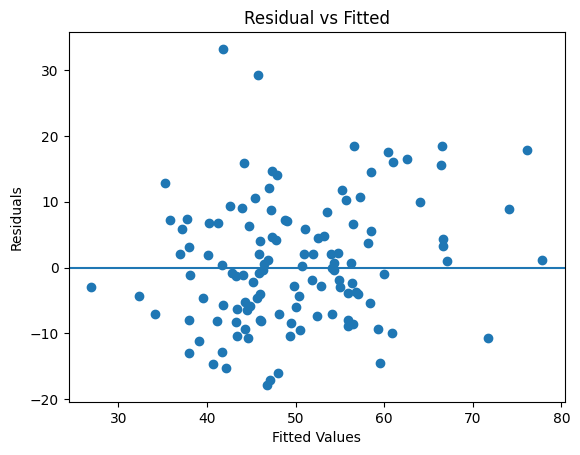

In [16]:
residuals = y_test - y_test_pred

plt.scatter(y_test_pred, residuals)
plt.axhline(0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted")
plt.show()

In [5]:
df = pd.read_csv("ipl_male_csv2/1527690.csv", nrows = 20)
ashwin_string = df.to_csv(index = False)
print(ashwin_string)

match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
1527690,2026,2026-04-11,"Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh",1,0.1,Sunrisers Hyderabad,Punjab Kings,Abhishek Sharma,TM Head,Arshdeep Singh,0,1,1.0,,,,,,,,
1527690,2026,2026-04-11,"Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh",1,0.2,Sunrisers Hyderabad,Punjab Kings,Abhishek Sharma,TM Head,Arshdeep Singh,4,0,,,,,,,,,
1527690,2026,2026-04-11,"Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh",1,0.3,Sunrisers Hyderabad,Punjab Kings,Abhishek Sharma,TM Head,Arshdeep Singh,1,0,,,,,,,,,
1527690,2026,2026-04-11,"Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh",1,0.4,Sunrisers Hyderabad,Punjab Kings,TM Head,Abhishek Sharma,Arshdeep Singh,0,1,1.0,,,,,,,,
1527690,2026,2